In [3]:

#California Housing Price Prediction
#Project Statement
#This project aims to predict median house prices in California using demographic and housing features.

## Objectives
#Clean dataset and handle missing values
#Perform exploratory data analysis
#Select important features using correlation
#Build regression model
#Evaluate model performance


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
df = pd.read_csv("housing.csv.zip")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
df.shape

(20640, 10)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [11]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [17]:
df.fillna(df.median(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

In [24]:
# Only apply to numeric columns
numeric_df = df.select_dtypes(include=['number'])
q1 = numeric_df.quantile(0.25)
q3 = numeric_df.quantile(0.75)
iqr = q3-q1
df = df[~((numeric_df<(q1-1.5*iqr)) | (numeric_df > (q3+1.5*iqr))).any(axis=1)]

In [27]:
#check datatype
print(df.dtypes)
#check for non numeric columns
print(df.select_dtypes(exclude=['number']).columns)

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object
Index(['ocean_proximity'], dtype='object')


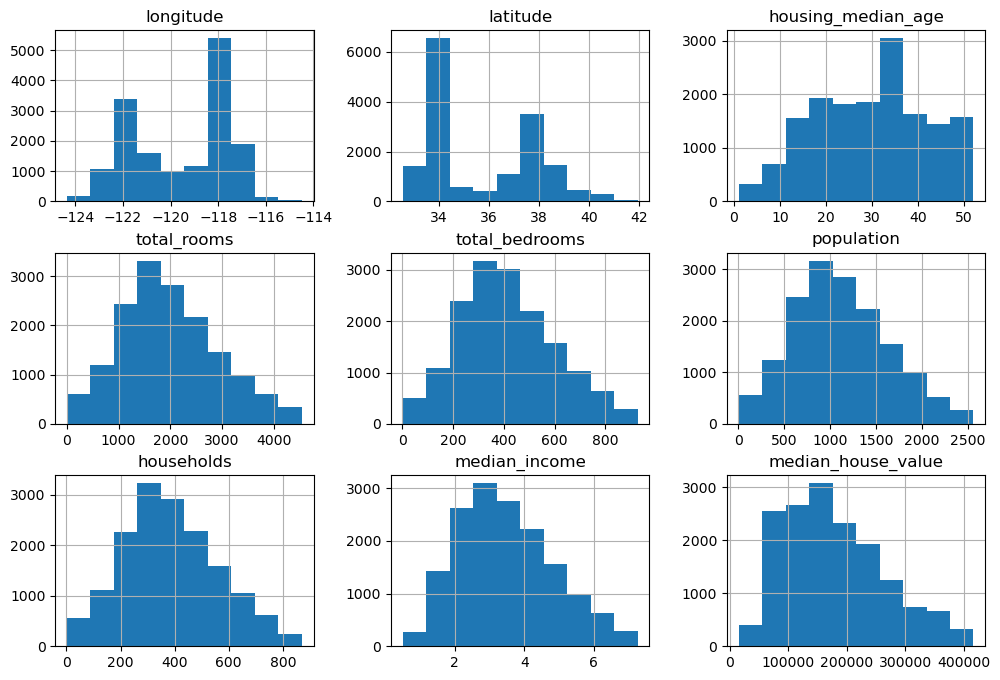

In [28]:
df.hist(figsize=(12,8))
plt.show()

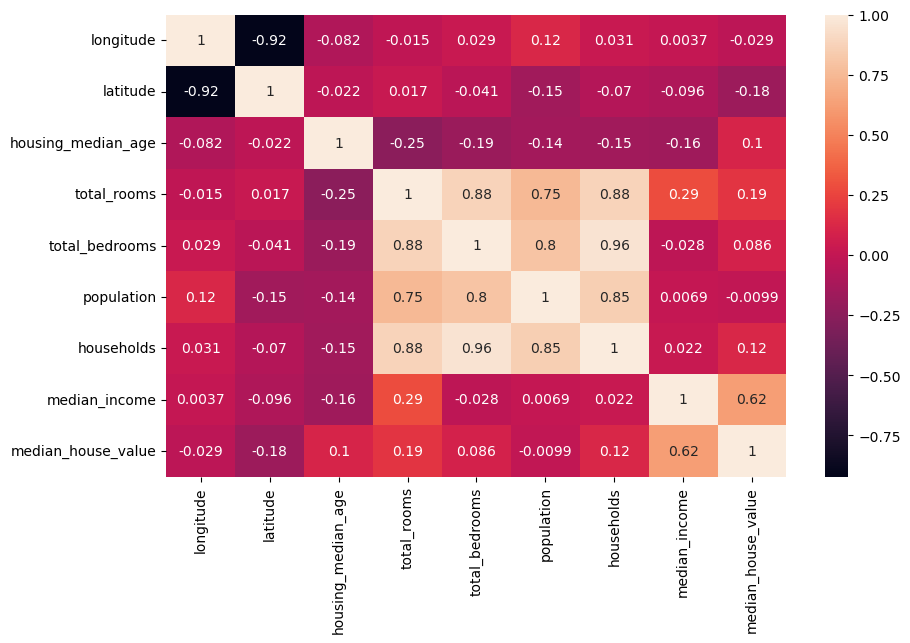

In [31]:
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),annot=True)
plt.show()

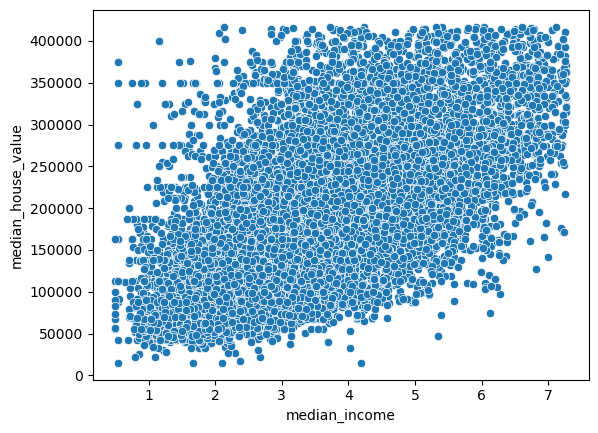

In [33]:
sns.scatterplot(x='median_income', y='median_house_value',data=df)
plt.show()

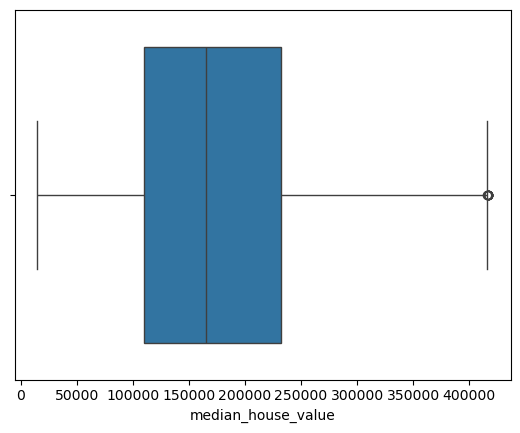

In [34]:
sns.boxplot(x=df['median_house_value'])
plt.show()

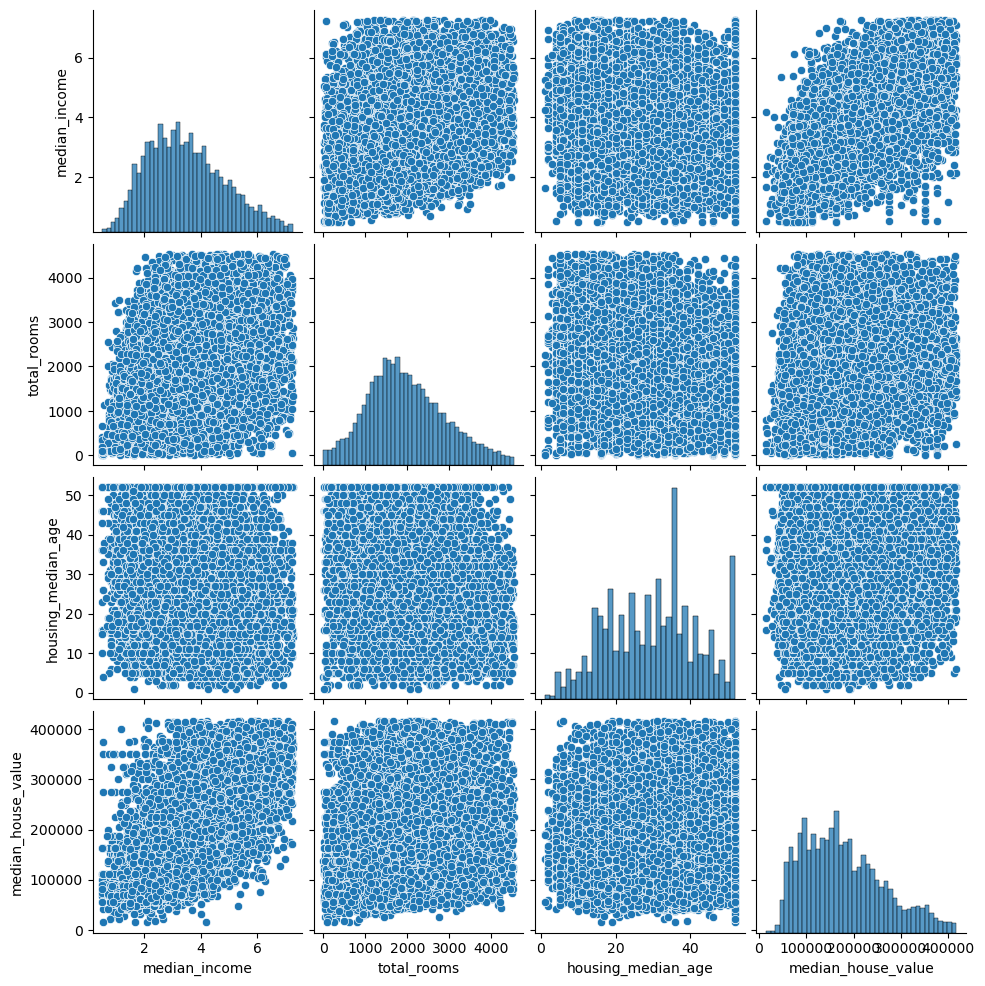

In [35]:
sns.pairplot(df[['median_income','total_rooms','housing_median_age','median_house_value']])
plt.show()

In [36]:
#FEATURE SELECTION

In [40]:
#Correlation with target

#Using select_dtypes to filter only numerical columns before calculating correlation
numerical_df = df.select_dtypes(include=['number'])  # This excludes string/categorical columns
corr = numerical_df.corr()
corr['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.622658
total_rooms           0.187265
households            0.120338
housing_median_age    0.100475
total_bedrooms        0.086250
population           -0.009887
longitude            -0.028877
latitude             -0.176941
Name: median_house_value, dtype: float64

In [42]:
X = df[['median_income','total_rooms','housing_median_age']]
y = df['median_house_value']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [48]:
#building regression model
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
#prediction
y_pred = model.predict(X_test)

In [51]:
#model evaluation
r2_score(y_test, y_pred)
mean_squared_error(y_test, y_pred)

4159058748.6309967

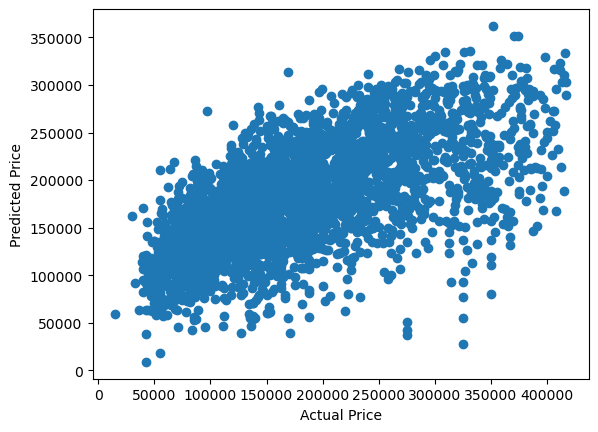

In [52]:
#visualization of results
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()